#### PROJECT GOAL
This project focuses on the design and implementation of a custom Convolutional Neural Network (CNN) engineered to detect synthetic artifacts and distinguish AI-generated images from authentic media. Utilizing the 
[Kaggle CiFAKE Dataset](https://www.kaggle.com/datasets/doctorstrange420/cifake-dataset) from Kaggle, the custom architecture's performance is benchmarked against fine-tuned, pre-trained computer vision networks, specifically ResNet and DenseNet. To ensure transparency and model auditability, the pipeline integrates Explainable AI (XAI) methodologies to map and analyze the specific visual features driving the network's classification decisions.

#### Check dependencies and set up the system

In [45]:
# import libraries
import tensorflow as tf
import os
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import Accuracy, Precision, Recall

In [2]:
print(f'TensorFlow version intsalled : {tf.__version__}')

TensorFlow version intsalled : 2.19.1


In [3]:
# path for data dict
path = 'data'  

In [4]:
# limit GPU usage
gpus = tf.config.experimental.list_physical_devices('GPU')

In [5]:
# check number of gpus :
print(f'Total available GPUs {len(gpus)}')

Total available GPUs 1


In [6]:
# limit memory growth
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

### Cleaning the data

In [7]:
# check files in the data dir
os.listdir(path)

['REAL', 'FAKE']

We will remove any unnecessary files from the data directory, remove currput images or images with invalid extensions.

In [8]:
# define valid extensions
img_exts = ['.png', '.jpeg', '.jpg', '.bmp']
removed_files = 0
 

# loop thru each sub-dir in the main data dir
for dir_name in os.listdir(path):
    dir_path = os.path.join(path, dir_name)

    # hidden directory/file check at the root level
    if dir_name.startswith('.') or dir_name == 'thumbs.db':
        if os.path.exists(dir_path):
            if os.path.isdir(dir_path):
                # to safely handle root-level folders like .ipynb_checkpoints
                shutil.rmtree(dir_path)  
            else:
                os.remove(dir_path)
            removed_files += 1
        continue
        
    if not os.path.isdir(dir_path):
        continue

    # loop thru each image in subdir
    for img_name in os.listdir(dir_path):
        img_path = os.path.join(dir_path, img_name)

        # 1. Hidden file check (handles internal checkpoints/system files)
        if img_name.startswith('.') or img_name == 'thumbs.db':
            print(f'Removing hidden/system file or folder: {img_name}')
            if os.path.exists(img_path):
                if os.path.isdir(img_path):
                    shutil.rmtree(img_path)  # Handles nested folders like data/FAKE/.ipynb_checkpoints
                else:
                    os.remove(img_path)
                removed_files += 1
            continue  # <- Safely jump to the next file

        # 2. Extracted extension format check
        ext = os.path.splitext(img_path)[1].lower()
        if ext not in img_exts:
            print(f'Removing image {img_path} with invalid extension {ext}')
            if os.path.exists(img_path):
                if os.path.isdir(img_path):
                    shutil.rmtree(img_path)
                else:
                    os.remove(img_path)
                removed_files += 1
            continue  # <- Safely jump to the next file

        # 3. TensorFlow Integrity Check
        try:
            img_raw = tf.io.read_file(img_path)
            tf.io.decode_image(img_raw, channels=3, expand_animations=False)

        except Exception as e:
            print(f'Corrupt file found... {img_path}! Removing it...')
            if os.path.exists(img_path):
                if os.path.isdir(img_path):
                    shutil.rmtree(img_path)
                else:
                    os.remove(img_path)
                removed_files += 1

print(f'\nTotal {removed_files} files/folders removed during the checking process.')

2026-06-05 16:04:36.416627: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-05 16:04:36.416653: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-05 16:04:36.416656: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1780689876.416939  467269 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780689876.416965  467269 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Total 0 files/folders removed during the checking process.


### Data loading

In [9]:
train = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,    # Reserves 20% for validation + testing
    subset="training",
    seed=42,                 # Seed must match the validation call exactly!
    label_mode='int',
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

# Load the remaining 20% validation/test pool
val_test_pool = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,    # Reserves the same 20% 
    subset="validation",
    seed=42,                 # Seed must match the training call exactly!
    label_mode='int',
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

# Split the 20% pool in half to create distinct Validation and Test sets (10% / 10% overall)
val_batches = tf.data.experimental.cardinality(val_test_pool).numpy()
val_size = val_batches // 2

val = val_test_pool.take(val_size)
test = val_test_pool.skip(val_size)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.
Found 20000 files belonging to 2 classes.
Using 4000 files for validation.


We will verify a few images in the dataset:

In [10]:
# load data to iterator
data_iterator = train.as_numpy_iterator()

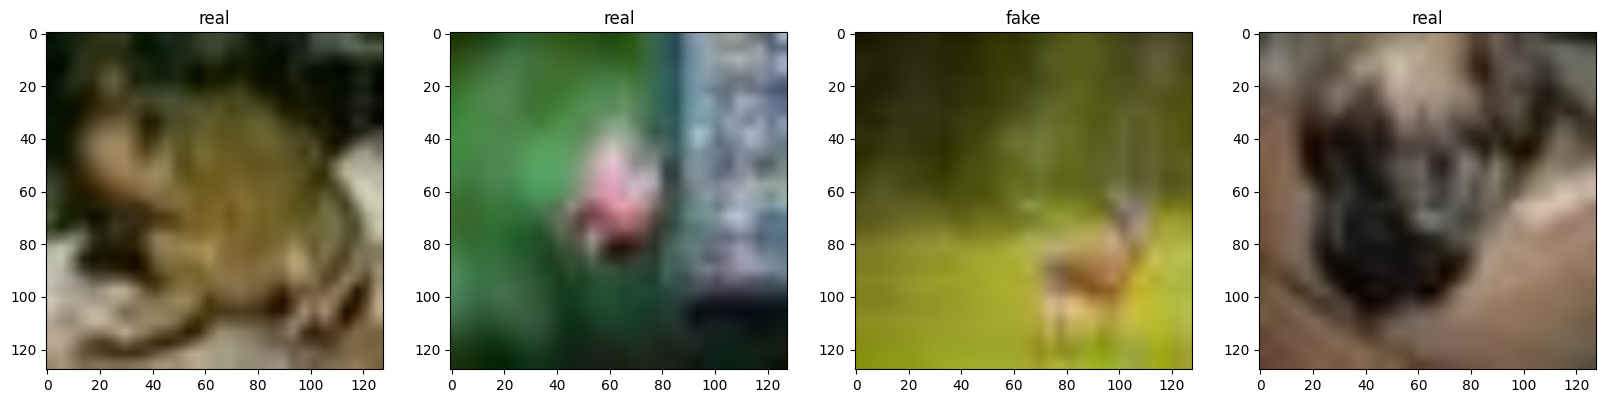

In [11]:
batch1 = data_iterator.next()
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))

class_map = {
    0 : 'fake',
    1 : 'real'
            }
for idx, img in enumerate(batch1[0][:4]):
    ax[idx].imshow(img.astype(int))
    title = class_map[batch1[1][idx]]
    ax[idx].title.set_text(title)

In [12]:
# checking size of train, test and validation splits
print(f'train set size: {len(train)}')
print(f'Validation size: {len(val)}') 
print(f'test: {len(test)}') 

train set size: 500
Validation size: 62
test: 63


### Augmenting the dataset

In [13]:
# data augmentation pipeline
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomBrightness(0.1)
])

# get autotune for randomness
AUTOTUNE = tf.data.AUTOTUNE

#### Optimize for performance using caching and prefetching

In [14]:
# augmenting, caching, and prefetching the train data
# Shuffle training data so the network doesn't learn order bias
train = train.shuffle(buffer_size=len(train), seed=42)
train = train.cache()
train = train.map(lambda x, y : (data_augmentation(x), y), \
                      num_parallel_calls=AUTOTUNE)
train = train.prefetch(buffer_size=AUTOTUNE)

In [15]:
# caching and prefetching val data
val = val.cache()
val = val.prefetch(buffer_size=AUTOTUNE)

In [16]:
# caching and prefetching test data
test = test.cache()
test = test.prefetch(buffer_size=AUTOTUNE)

Next, we will verify if some class imbalance exists in the datasets:

In [17]:
# 1. Count the labels in the training dataset
all_labels_train = []

for _, labels in train.unbatch():
    all_labels_train.append(labels.numpy())

all_labels_train = np.array(all_labels_train)
total_train = len(all_labels_train)
num_fake_train = np.sum(all_labels_train == 0)
num_real_train = np.sum(all_labels_train == 1)

print(f'total samples : {total_train}')
print(f'Total fake samples : {num_fake_train}')
print(f'total real samples : {num_real_train}') 

2026-06-05 16:04:41.433130: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


total samples : 16000
Total fake samples : 8044
total real samples : 7956


2026-06-05 16:04:43.080309: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
# 2. Count the labels in the validation dataset
all_labels = []

for _, labels in val.unbatch():
    all_labels.append(labels.numpy())

all_labels = np.array(all_labels)
total_samples = len(all_labels)
num_fake = np.sum(all_labels == 0)
num_real = np.sum(all_labels == 1)

print(f'total samples : {total_samples}')
print(f'Total fake samples : {num_fake}')
print(f'total real samples : {num_real}') 

total samples : 1984
Total fake samples : 951
total real samples : 1033


2026-06-05 16:04:43.190421: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
# 3. Count the labels in the test dataset
all_labels = []

for _, labels in test.unbatch():
    all_labels.append(labels.numpy())

all_labels = np.array(all_labels)
total_samples = len(all_labels)
num_fake = np.sum(all_labels == 0)
num_real = np.sum(all_labels == 1)

print(f'total samples : {total_samples}')
print(f'Total fake samples : {num_fake}')
print(f'total real samples : {num_real}') 

total samples : 2016
Total fake samples : 1002
total real samples : 1014


In [20]:
# 2. Calculate balanced class weights
# Formula: total_samples / (num_classes * num_samples_in_class)
weight_0 = total_train / (2 * num_fake_train)
weight_1 = total_train / (2 * num_real_train)
class_weights = { 0 : weight_0,
                  1 : weight_1
                }
print(f"Calculated Class Weights: {class_weights}")

Calculated Class Weights: {0: np.float64(0.9945300845350572), 1: np.float64(1.0055304172951232)}


### Model building
#### Building the Custom Baseline CNN

In [21]:
def build_custom_cnn(input_shape=(128, 128, 3)):
    model = models.Sequential([

        # Input and Normalization
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),

        # Block1: Edges, corners, early-textures, and lines
        layers.Conv2D(32, (3, 3), 1, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),

        # Block2: Mid-level structural artifacts
        layers.Conv2D(64, (3, 3), 1, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),

        # Block3: High-frequency Generative Patterns
        layers.Conv2D(128, (3, 3), 1, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),

        # Dense Classification Head
        # layers.Flatten(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

In [22]:
# Instantiate and compile the baseline model
baseline_model = build_custom_cnn()
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.TruePositives(name='tp'),
            tf.keras.metrics.FalsePositives(name='fp'),
            tf.keras.metrics.TrueNegatives(name='tn'),
            tf.keras.metrics.FalseNegatives(name='fn')
            ]
)

# get baseline summary
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,425 (497.75 KB)

 Trainable params: 126,977 (496.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
# dir to save training logs
logdir = 'logs'

In [24]:
# define callback
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [25]:
# train model 
hist = baseline_model.fit(train, validation_data=val,\
                          epochs=15, class_weight=class_weights, \
                          callbacks=[tensorboard_callback])

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.6556 - fn: 2581.0000 - fp: 2929.0000 - loss: 0.6294 - precision: 0.6473 - recall: 0.6756 - tn: 5115.0000 - tp: 5375.0000 - val_accuracy: 0.5585 - val_fn: 3.0000 - val_fp: 873.0000 - val_loss: 0.6864 - val_precision: 0.5413 - val_recall: 0.9971 - val_tn: 78.0000 - val_tp: 1030.0000
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.7349 - fn: 1875.0000 - fp: 2366.0000 - loss: 0.5378 - precision: 0.7199 - recall: 0.7643 - tn: 5678.0000 - tp: 6081.0000 - val_accuracy: 0.8140 - val_fn: 118.0000 - val_fp: 251.0000 - val_loss: 0.4352 - val_precision: 0.7847 - val_recall: 0.8858 - val_tn: 700.0000 - val_tp: 915.0000
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.7720 - fn: 1654.0000 - fp: 1994.0000 - loss: 0.4803 - precision: 0.7596 - recall: 0.7921 - tn: 6050.0000 - tp: 6302.0000 - val_accuracy: 0.8397 - val_fn: 113.0000 - val_fp: 205.0000 - val_loss: 0.3868 - val_precision: 0.8178 - val

#### create performance plots

Text(0.5, 1.0, 'Base CNN model accuracy plots')

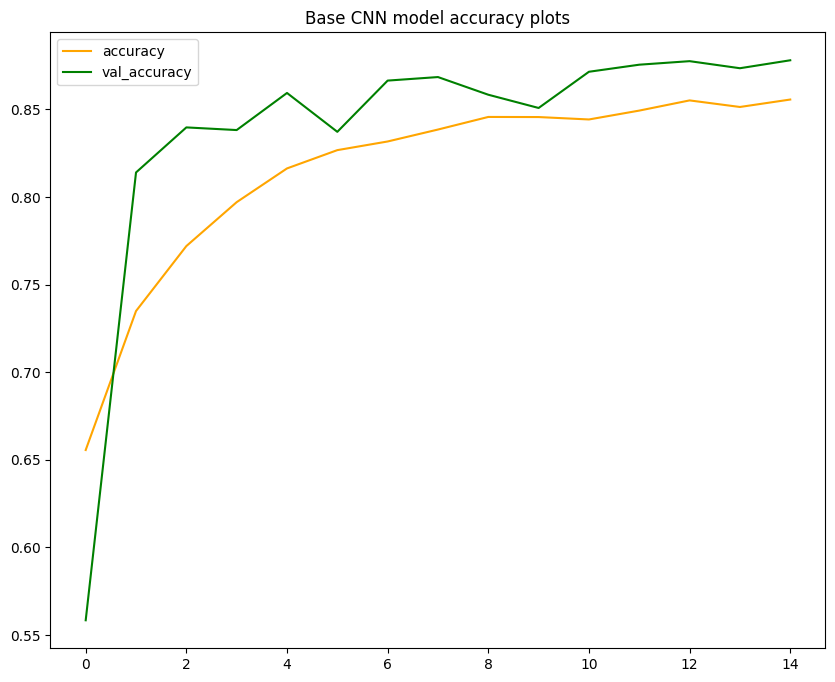

In [26]:
# accuracy plot
plt.figure(figsize=(10, 8))
plt.plot(hist.history['accuracy'] , color='orange', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='green', label = 'val_accuracy')
plt.legend(loc = 'upper left')
plt.title("Base CNN model accuracy plots")

Text(0.5, 1.0, 'Base CNN model loss plots')

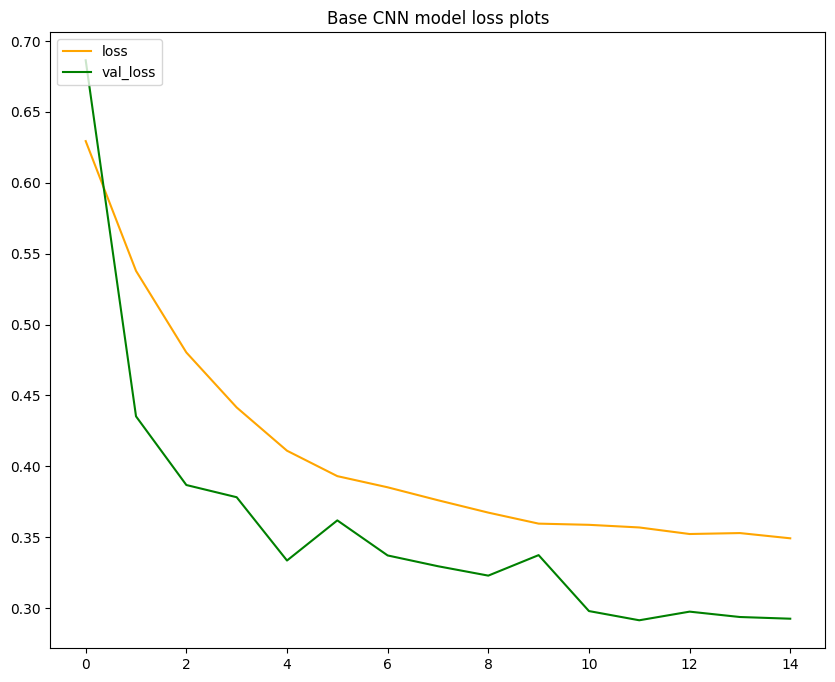

In [27]:
# loss plot
plt.figure(figsize=(10, 8))
plt.plot(hist.history['loss'] , color='orange', label='loss')
plt.plot(hist.history['val_loss'], color='green', label = 'val_loss')
plt.legend(loc = 'upper left')
plt.title("Base CNN model loss plots")

#### check model performance on the test set

In [28]:
pre = Precision()
acc = Accuracy()
rec = Recall()

In [29]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = baseline_model.predict(X, verbose=0)
    yhat = (yhat > 0.5).astype(int)
    yhat = yhat.flatten()
    pre.update_state(y, yhat)
    acc.update_state(y, yhat)
    rec.update_state(y, yhat)

2026-06-05 16:11:30.980426: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [30]:
print('Test dataset results:-')
print(f'Precision : {(pre.result().numpy()):.4f}')
print(f'Accuracy : {acc.result().numpy():.4f}')
print(f'Recall : {rec.result().numpy():.4f}')

Test dataset results:-
Precision : 0.9035
Accuracy : 0.8745
Recall : 0.8402


In [31]:
# save the baseline model
baseline_model.save(os.path.join('baseline_cnn.keras'))

#### Next, we will compare our baseline model's performance with popular pre-trained models like ResNet and DenseNet:

In [32]:
def build_from_pretrained(input_shape=(128, 128, 3), architecture='resnet'):
    """
    Function to create a trainable model 
    from pretrained models
    with embedded preprocessing
    """

    # define keras input node
    inputs = tf.keras.layers.Input(shape=input_shape)

    # define pre-trained model with 
    # architecture-specific internal preprocessing
    if architecture == 'resnet':
        # 1. Apply ResNet-specific preprocessing layer (scales to [-1, 1])
        preprocessed_inputs =\
        tf.keras.applications.resnet_v2.preprocess_input(inputs)
        
        base_model = tf.keras.applications.ResNet50V2(
            include_top=False,
            weights='imagenet',
            # Pass the preprocessed tensor here
            input_tensor=preprocessed_inputs, 
            pooling='avg'
        )
    elif architecture == 'densenet':
        # 2. Apply DenseNet-specific preprocessing layer
        # (ImageNet mean/std normalization)
        preprocessed_inputs =\
        tf.keras.applications.densenet.preprocess_input(inputs)
        
        base_model = tf.keras.applications.DenseNet121(
            include_top=False,
            weights='imagenet',
            # Pass the preprocessed tensor here
            input_tensor=preprocessed_inputs, 
            pooling='avg'
        )
        
    # Allow the network to adapt its 
    # filters to synthetic artifact textures
    base_model.trainable = True

    # output from the baseline model
    x = base_model.output

    # adding a dropout layer
    x = tf.keras.layers.Dropout(0.3)(x)

    # adding top layer (Sigmoid output 
    # for your balanced binary dataset)
    outputs =\
    tf.keras.layers.Dense(1, activation='sigmoid')(x)
    
    # Construct the final functional model map
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    return model

In [33]:
resnet = build_from_pretrained()

In [34]:
resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(),
             tf.keras.metrics.Recall(),
             tf.keras.metrics.TruePositives(),
             tf.keras.metrics.FalsePositives(),
             tf.keras.metrics.TrueNegatives(),
             tf.keras.metrics.FalseNegatives()
            ])
    

In [35]:
# checking model parameters
resnet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 128, 128,  │          0 │ input_layer_2[0]… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 128, 128,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ subtract[0][0]    │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 32, 32,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 32, 32,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 34, 34,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_pre

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 23,521,409 (89.73 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [36]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir='resnet_logs')
resnet_hist = resnet.fit(train, epochs=15, validation_data=val, class_weight=class_weights,  callbacks=[tensorboard_callback])

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 186s 321ms/step - accuracy: 0.7125 - false_negatives: 2541.0000 - false_positives: 2059.0000 - loss: 0.5566 - precision_1: 0.7245 - recall_1: 0.6806 - true_negatives: 5985.0000 - true_positives: 5415.0000 - val_accuracy: 0.8523 - val_false_negatives: 161.0000 - val_false_positives: 132.0000 - val_loss: 0.3433 - val_precision_1: 0.8685 - val_recall_1: 0.8441 - val_true_negatives: 819.0000 - val_true_positives: 872.0000
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 183s 365ms/step - accuracy: 0.8724 - false_negatives: 1034.0000 - false_positives: 1007.0000 - loss: 0.3055 - precision_1: 0.8730 - recall_1: 0.8700 - true_negatives: 7037.0000 - true_positives: 6922.0000 - val_accuracy: 0.9022 - val_false_negatives: 124.0000 - val_false_positives: 70.0000 - val_loss: 0.2370 - val_precision_1: 0.9285 - val_recall_1: 0.8800 - val_true_negatives: 881.0000 - val_true_positives: 909.0000
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - accuracy: 0.9070 - 

#### check model training performance

Text(0.5, 1.0, 'ResNet model accuracy plots')

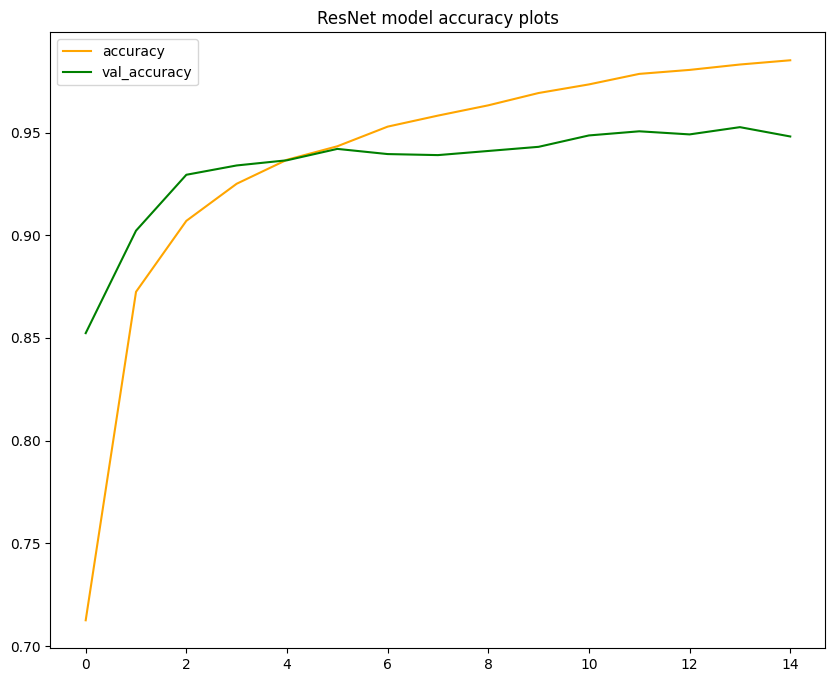

In [37]:
# create accuracy plots
plt.figure(figsize=(10, 8))
plt.plot(resnet_hist.history['accuracy'] , color='orange', label='accuracy')
plt.plot(resnet_hist.history['val_accuracy'], color='green', label = 'val_accuracy')
plt.legend(loc = 'upper left')
plt.title("ResNet model accuracy plots")

Text(0.5, 1.0, 'ResNet model loss plots')

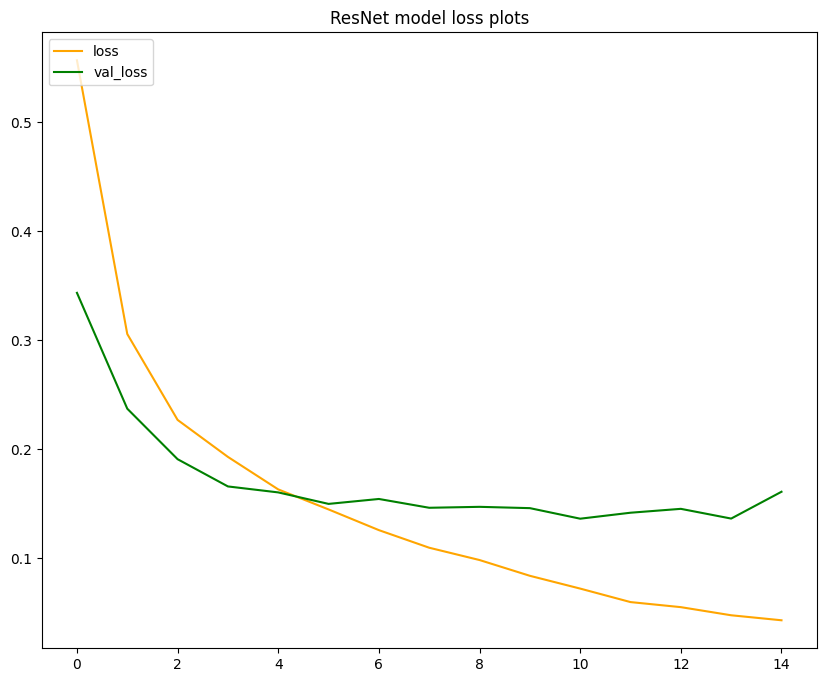

In [38]:
# create loss plots
plt.figure(figsize=(10, 8))
plt.plot(resnet_hist.history['loss'] , color='orange', label='loss')
plt.plot(resnet_hist.history['val_loss'], color='green', label = 'val_loss')
plt.legend(loc = 'upper left')
plt.title("ResNet model loss plots")

In [39]:
# checking model performance with a test set
pre_resnet = Precision()
acc_resnet = Accuracy()
rec_resnet = Recall()

for batch in test.as_numpy_iterator():
    images, labels = batch
    yhat = resnet.predict(images, verbose=0)
    yhat = (yhat > 0.5).astype(int)
    yhat = yhat.flatten()
    pre_resnet.update_state(yhat, labels)
    acc_resnet.update_state(yhat, labels)
    rec_resnet.update_state(yhat, labels)

print(f'ResNet performance on the test set:')
print(f'Accuracy : {acc_resnet.result().numpy() :.4f}')
print(f'Precision: {pre_resnet.result().numpy() :.4f}')
print(f'Recall: {rec_resnet.result().numpy() :.4f}')

ResNet performance on the test set:
Accuracy : 0.9449
Precision: 0.9181
Recall: 0.9708


## build densenet model
densenet = build_from_pretrained(architecture='densenet')


densenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(),
             tf.keras.metrics.Recall(),
             tf.keras.metrics.TruePositives(),
             tf.keras.metrics.FalsePositives(),
             tf.keras.metrics.TrueNegatives(),
             tf.keras.metrics.FalseNegatives()
            ])

callback_densenet = tf.keras.callbacks.TensorBoard(log_dir='densenet_logs')
hist_densenet = densenet.fit(train, epochs=5, validation_data=val, callbacks=[callback_densenet])

# checking model performance with a test set
pre_densenet = Precision()
acc_densenet = Accuracy()
rec_densenet = Recall()

for batch in test.as_numpy_iterator():
    images, labels = batch
    yhat = densenet.predict(images, verbose=0)
    yhat = (yhat > 0.5).astype(int)
    yhat = yhat.flatten()
    pre_densenet.update_state(yhat, labels)
    acc_densenet.update_state(yhat, labels)
    rec_densenet.update_state(yhat, labels)

print(f'ResNet performance on the test set:')
print(f'Accuracy : {acc_densenet.result().numpy() :.4f}')
print(f'Precision: {pre_densenet.result().numpy() :.4f}')
print(f'Recall: {rec_densenet.result().numpy() :.4f}')

#### Now we will evaluate the model's decision using Grad-CAM

In [41]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """
    Computes a Grad-CAM heatmap supporting both flat sequential models 
    and deeply nested transfer learning backbones (ResNet/DenseNet).
    """
    # 1. Recursively find the target layer's symbolic output tensor within the main graph
    target_layer_output = None
    
    # Check top-level layers first
    try:
        target_layer_output = model.get_layer(last_conv_layer_name).output
    except ValueError:
        # Look inside nested containers if it's not at the top level
        for layer in model.layers:
            if hasattr(layer, 'layers'):  # Identifies inner sub-models
                try:
                    target_layer_output = layer.get_layer(last_conv_layer_name).output
                    break
                except ValueError:
                    continue

    if target_layer_output is None:
        raise ValueError(f"Could not locate target layer '{last_conv_layer_name}' inside the model architecture.")

    # 2. Build a stable functional sub-graph mapped to the main model input
    # This prevents sub-graph input disconnects for transfer learning backbones
    try:
        grad_model = tf.keras.models.Model(
            inputs=model.input,
            outputs=[target_layer_output, model.output]
        )
    except (AttributeError, ValueError):
        # Fallback for unbuilt Sequential containers
        input_shape = model.input_shape[1:] if isinstance(model.input_shape, tuple) else model.input_shape[0][1:]
        img_input = tf.keras.layers.Input(shape=input_shape)
        
        x = img_input
        conv_output = None
        for layer in model.layers:
            x = layer(x)
            if layer.name == last_conv_layer_name:
                conv_output = x
        grad_model = tf.keras.models.Model(inputs=img_input, outputs=[conv_output, x])

    # 3. Compute gradients with respect to the prediction score target
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        tape.watch(img_tensor)
        
        conv_outputs, predictions = grad_model(img_tensor)
        score = predictions[0][0]
        
        # Maximize the logit optimization vector depending on prediction outcomes
        # Ensures clean gradient vectors even on highly confident predictions (0.000 or 1.000)
        loss = -score if score < 0.5 else score

    # 4. Extract gradients relative to the chosen convolutional activation space
    grads = tape.gradient(loss, conv_outputs)

    # 5. Handle pooling math across spatial dimensions
    # For Flatten() backends, axis=(0,1,2) extracts channel importance accurately
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Weigh the individual feature channels
    conv_outputs = conv_outputs[0]
    pooled_grads = tf.cast(pooled_grads, conv_outputs.dtype)
    
    # Project the weights back onto the spatial feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Apply standard Grad-CAM ReLU activation and normalize safely
    heatmap = tf.maximum(heatmap, 0.0)
    max_val = tf.reduce_max(heatmap)
    
    if max_val > 0.0:
        heatmap = heatmap / max_val
    else:
        heatmap = tf.zeros_like(heatmap)
        
    return heatmap.numpy()
 
    


def save_and_display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))

    # Rescale heatmap to a range of 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to convert single-channel heatmap to a vibrant color map
    jet = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    jet = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)

    # Resize the heatmap to match the original image dimensions
    jet = cv2.resize(jet, (img.shape[1], img.shape[0]))

    # Superimpose the heatmap on original image
    superimposed_img = jet * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # Plot the original, the raw heatmap, and the superimposed output side-by-side
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis("off")
    
    ax[1].imshow(heatmap, cmap="jet")
    ax[1].set_title("Raw Heatmap")
    ax[1].axis("off")
    
    ax[2].imshow(superimposed_img)
    ax[2].set_title("Grad-CAM Activation Map")
    ax[2].axis("off")
    
    plt.show()

In [42]:
def process_raw_img(img_path, target_size = (128, 128)):

    img = tf.keras.utils.load_img(img_path, target_size=target_size)

    img_array = tf.keras.utils.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    return img_array

for i in reversed(baseline_model.layers):
    if isinstance(layer, tf.keras.Model):
        print(layer)
        break

for layer in reversed(baseline_model.layers):
        # We look for Conv2D, Concat blocks, or final activations like 'relu' or 'post_relu'
        if isinstance(layer, tf.keras.layers.Conv2D) or \
           'concat' in layer.name or \
           'conv' in layer.name or \
           layer.name == 'relu' or \
           layer.name == 'post_relu':
            print(layer)
            break

In [43]:
pwd

'/Users/amalchaturvedi/Desktop/Arnima_projects/deepFakeVsReal'

255.0

--- Model 1: sequential_1 ---
Detected Target Conv Layer: 'conv2d_2'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Prediction: 0.0000 (FAKE) -> Tracking synthetic artifacts.


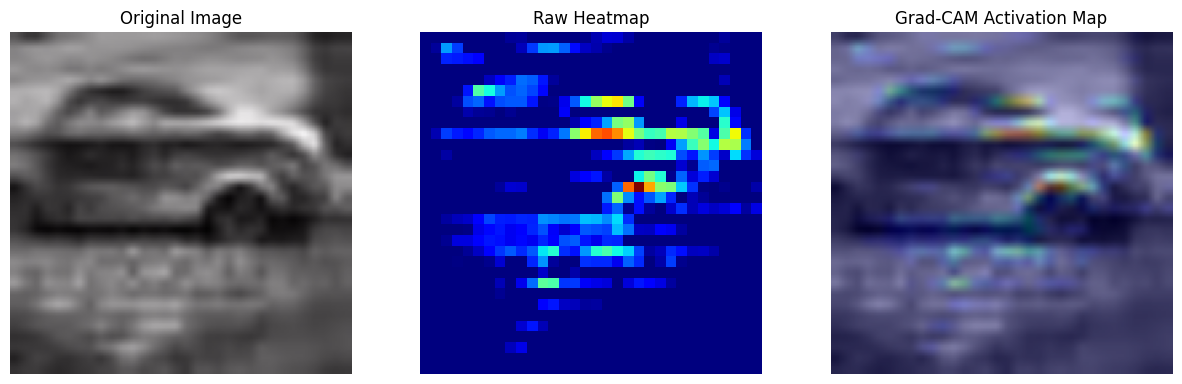


--- Model 2: functional_2 ---
Detected Target Conv Layer: 'post_relu'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
Prediction: 0.0000 (FAKE) -> Tracking synthetic artifacts.


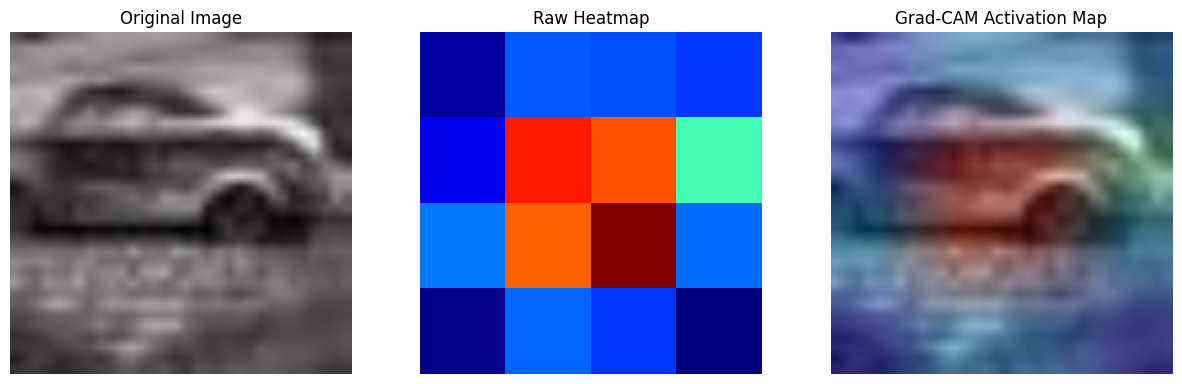

In [46]:
models_f = [baseline_model, resnet]

# Prepare image array with batch dimension (1, 128, 128, 3)
img_path = "test_img.jpg"
img_array = process_raw_img(img_path)
print(np.max(img_array))


for i, model in enumerate(models_f):
    last_conv_layer_name = None
    target_model_for_layer = model
    
    # 1. Drill down to find the correct sub-model space if nested
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.Model): 
            target_model_for_layer = layer
            break

    # 2. Extract the exact target layer string name
    for layer in reversed(target_model_for_layer.layers):
        if isinstance(layer, tf.keras.layers.Conv2D) or \
           'concat' in layer.name or \
           'conv' in layer.name or \
           layer.name in ['relu', 'post_relu']:
            
            last_conv_layer_name = layer.name
            break

    print(f"\n--- Model {i+1}: {model.name} ---")
    print(f"Detected Target Conv Layer: '{last_conv_layer_name}'")

    # 3. Predict output
    prediction = model.predict(img_array)[0][0]
    if prediction < 0.5:
        print(f"Prediction: {prediction:.4f} (FAKE) -> Tracking synthetic artifacts.")      
    else:
        print(f"Prediction: {prediction:.4f} (REAL) -> Tracking authentic textures.")

    
    
    # --- FIX HERE: Pass the main top-level model wrapper ---
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
        
    # 4. Render the comparative plot
    save_and_display_gradcam(img_path, heatmap)

custom model retains high spatial resolution at the final layer. This allows Grad-CAM to map gradients back to exact pixel boundaries. It is scanning the image like a magnifying glass, picking up on high-frequency noise, edge discontinuities, and specific texture artifacts along the window lines and windshield borders.

Whereas ResNet compresses the image into a tiny $4 \times 4$ semantic grid, it is forced to look at the global composition. It highlights the center of the car because it's evaluating the macro-structure of the object as a whole, lacking the spatial resolution to pinpoint tiny individual pixels.